# Unified plotting for Laughter paper: Line Dancing Lesson

extract physiological measurements and audio from externally hosted data, import annotation files describing dance events and laughter, compose plots for paper

In [1]:
import sys
import os
import time

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

import librosa

from scipy import interpolate

In [2]:
%load_ext autoreload
%autoreload 1
%aimport mh
%aimport rp2
%aimport viz
%aimport qex

In [3]:
 %reload_ext autoreload

# Import data constellation

In [10]:
Event = 'Linedancing'
audio_loc ='../Linedancing/Recordings/'
misc_loc = './datain/'
data_out = './dataout/'
phys_dir = '../Linedancing/Phys/'
plot_loc = './plots/'

df_allfeats = {}


In [11]:
# eq
df_files = pd.DataFrame(columns=['PartID','NID','Performance','Segment','Signal','Measure','FileLoc'])
k = 0
for path, subdirs, files in os.walk(phys_dir):
    for f in files:
        fileloc = os.path.join(path, f)
        dets = f.split('_')
        measure = dets[-1]
        if measure.endswith('.csv'):
            measure = measure[:-4]
            signal = measure[-3:]
            if signal == 'ATA': signal = 'DATA'
            if signal == 'ESP': signal = 'RESP'
            if len(dets)==4:
                    df_files.loc[k,:] = {'PartID':dets[2],'NID':int(dets[2][2:5]),'Performance':dets[0],'Segment':dets[1],'Signal':signal,'Measure':measure,'FileLoc':fileloc}
                    k+=1
PhysFiles = df_files.copy()


In [16]:
subfiles = df_files

sections = {'Lead':['AU817'],
           'Better':['AU819', 'AU808', 'AU812', 'AU802', 'AU813', 'AU807', 'AU801'],
           'Mid':['AU804','AU814','AU803', 'AU810', 'AU815', 'AU806','AU818']} 

Row_Order = ['AU817', 'AU819', 'AU808', 'AU812', 'AU802', 'AU813', 'AU807', 'AU801', 'AU804','AU814','AU803', 'AU810', 'AU815', 'AU806','AU818']

players = Row_Order
section_pallet ={'Lead':[0.2,0.2, 0.7], 'Better':[0.7, 0.1, 0.1],  'Mid':[0.6, 0.1, 0.4],}

player_pallet = {}
collist = []
sectag = []
seccount = []
sectick = []
alist = []
i=0
for k in sections.keys():
    c = np.array(section_pallet[k])
    d_c = c/(1.25*len(sections[k])) 
    c_i = 0
    sublist = []
    for s in sections[k]:
        if s in subfiles.PartID.values: 
            sublist.append(s)
            alist.append(s)
            player_pallet[s] = c - c_i*d_c 
    if len(sublist)>0:
        sectick.append(i)
        sectag.append(k) 
        i += len(sublist)/2
        seccount.append(i)
        i += len(sublist)/2
        i+=1
        for s in sublist: collist.append(s)
        collist.append(' ')
print([sectag,seccount,collist])

section_pallet = {'Lead':[0.5,0.5,0.5], 'Better':[0.2,0.2,0.2], 'Mid':'k'}

who_hatch = { 'Lead':'\\','Participant':'//', 'few':'xx', 'subset':'xx','group':None}

whats = ['Mistake','Negotiation','Difficulty','Novelty','Joyful','Joke','Other','InChatter']
what_palette = dict(zip(whats,list(sns.color_palette("bright",len(whats)))))

events_types = ['Demo','Practice','Music','Verbal','Applause']
eventType_pallet=dict(zip(events_types,['#94bbdf','#bbb0e4','#e9a2cc','#ff9d9d','#ca65be',])) #['#4d8f98','#4d8bce','#ca65be','#ff494c']
eventType_hatching=dict(zip(events_types,['*','.',None,'x','\\']))
eventType_code = dict(zip(['Demo','Practice','Music','Verbal','Applause'],['D','T','M','V','A']))
code_eventType = dict(zip(['D','T','M','V','A'],['Demo','Practice','Music','Verbal','Applause']))


[['Lead', 'Better', 'Mid'], [0.5, 5.5, 13.5], ['AU817', ' ', 'AU819', 'AU808', 'AU812', 'AU802', 'AU813', 'AU807', 'AU801', ' ', 'AU804', 'AU814', 'AU803', 'AU810', 'AU815', 'AU806', 'AU818', ' ']]


# Session measurements from vests and audio


In [19]:

# Motion
time_c = 'c_sTime'
concert = '0507'
piece = Event 

altT = np.arange(-10,770,0.01)
df = pd.DataFrame(index = altT, columns = collist) #Row_Order)
all_sigs = {}
for t in ['ACC_Vert','ACC_Lat','ACC_Long','ACC_QoM']: all_sigs[t] = df.copy()
        
for partID in alist:
    row = subfiles.query('PartID==@partID and Signal=="ACC" ').iloc[0]
    V = pd.read_csv(row['FileLoc']) 
    V_seg=V.copy()
    V_seg.loc[:,'qom'] = np.sqrt(np.square(V_seg.loc[:,[ 'Vert Accelerometer','Lat Accelerometer','Long Accelerometer']].diff()).sum(axis=1)).rolling(128).mean()
    times = V_seg[time_c]
    f = interpolate.interp1d(times,V_seg['Vert Accelerometer'],kind = 'linear')    
    all_sigs['ACC_Vert'].loc[:,partID] = f(altT)
    f = interpolate.interp1d(times,V_seg['Lat Accelerometer'],kind = 'linear')    
    all_sigs['ACC_Lat'].loc[:,partID] = f(altT)
    f = interpolate.interp1d(times,V_seg['Long Accelerometer'],kind = 'linear')    
    all_sigs['ACC_Long'].loc[:,partID] = f(altT)
    f = interpolate.interp1d(times,V_seg['qom'],kind = 'linear')    
    all_sigs['ACC_QoM'].loc[:,partID] = f(altT)
for t in ['ACC_Vert','ACC_Lat','ACC_Long','ACC_QoM']: df_allfeats[t] = all_sigs[t].copy()

df_feats = pd.DataFrame(index = altT,columns = collist)
sig = 'RespWave'
for partID in alist:
    row = subfiles.query('PartID==@partID and Signal=="RESP" ').iloc[0]
    R = pd.read_csv(row['FileLoc'])  # currently this defaults to altEQCIBI before the original signal
    R.set_index('c_sTime',inplace=True)
    if len(V)>10:
        Breaths = rp2.breath_cycles(rp2.EQ_Inspiration_Extract(R['Breathing']),R['Breathing'])
        R['Breathing']= (R['Breathing']-R['Breathing'].median())/Breaths['IDepth'].quantile(0.15)
        f = interpolate.interp1d(R.index,R['Breathing'],fill_value='extrapolate')
        df_feats.loc[:,partID] = f(altT) 
df_allfeats[sig] = df_feats.copy()

# heart rate
df_feats = pd.DataFrame(index = altT,columns = collist)
sig = 'normHR1bt'
# sig = 'HR10bt'
for partID in alist:
    row = subfiles.query('PartID==@partID and Signal=="IBI"').iloc[0]
    V = pd.read_csv(row['FileLoc'])  # currently this defaults to altEQCIBI before the original signal
    V = V.loc[V['Interbeat Interval (MS)']>0,:].copy()
    if len(V)>10:
        sig_t = V['c_sTime']
        sig_v = V['Interbeat Interval (MS)']
        IBI = mh.clean_IBI(sig_t,sig_v,activitytype='resp')
        HR = mh.ibi_feats(IBI.index,IBI.IBI.values,altT)
        df_feats.loc[:,partID] = HR[sig].values
df_allfeats[sig] = df_feats.copy()

df_smoothed = df_allfeats['normHR1bt'].copy()
for partID in Row_Order:
    HR = df_smoothed[partID]
    cutHR = HR[HR.notna()]
    cutT = HR[HR.notna()].index
    f = interpolate.interp1d(cutT,cutHR.values,fill_value='extrapolate',kind= 'linear')
    df_smoothed[partID] = f(df_smoothed.index)
df_smoothed = df_smoothed.where(df_smoothed>-0.2, other=-0.2 ) #df[:] = np.where( mask, 30, df ) 
df_smoothed = df_smoothed.where(df_smoothed<1.5, other=1.5) #df[:] = np.where( mask, 30, df ) 
df_allfeats[sig+'_smoothed'] = df_smoothed.copy()


Clipped!
Clipped!
Clipped!
Clipped!
Clipped!


In [20]:
# Audio
aud_file = audio_loc + Event + '.mp3'
y, sr = librosa.load(aud_file)
rms =librosa.feature.rms(y=y, frame_length=256, hop_length=64, center=True, pad_mode='constant')
times = librosa.times_like(rms,sr = sr, hop_length=64)

buff = 0 # no buffer for this audio
C = librosa.cqt(y=y, sr=sr)
C_db = librosa.amplitude_to_db(np.abs(C), ref=np.max)
times = (-buff+np.arange(len(C_db[0]))*(times[-1])/len(C_db[0])).round(3)
pitchticks = np.arange(7,84,12)
pitchticklabels=['C1','C2','C3','C4','C5','C6','C7']
C_df = pd.DataFrame(data=C_db).transpose()
C_df = C_df[C_df.columns[::-1]]
C_df.set_index(times,inplace = True)
df_allfeats['Audio_cqt'] = C_df.copy()


In [21]:
df_allfeats.keys()

dict_keys(['ACC_Vert', 'ACC_Lat', 'ACC_Long', 'ACC_QoM', 'RespWave', 'normHR1bt', 'normHR1bt_smoothed', 'Audio_cqt'])

### output of session recording features 

If trying to replicate the visualisations, working from the dataout files should suffice

In [22]:
data_out = './dataout/'

for feat in df_allfeats.keys():
    df_allfeats[feat].to_csv(data_out + Event +'_'+feat+'.csv')

### Align and interpret the annotation files, events and laughter¶

In [25]:
# Event annotations
Event_timings  = pd.read_csv(misc_loc+'Line_dance_timings3.csv')
Event_timings.loc[:,'Time'] = Event_timings.loc[:,'TIME'].astype('int')
Event_timings['DURATION'] = Event_timings['Dur']

dancings = pd.DataFrame()
dancings['TIME'] = Event_timings['StartTime']
dancings['DURATION'] = Event_timings['Dur']
dancings['LABEL'] = Event_timings['LABEL']

In [23]:
laughs = pd.read_csv(misc_loc+'Line_dancing_LaughNotes.csv')
laughs['Difficulty'] = laughs['Communicating difficulty']  # Communicating difficulty level (label: difficulty level) Communicating difficulty
laughs['Novelty'] =  laughs['Novelty and Surprise']
laughs['Other'] = laughs['External']
laughs['InChatter'] = laughs['In Chatter']
laughs['Negotiation'] =  laughs['Negociation']


# Full Plot

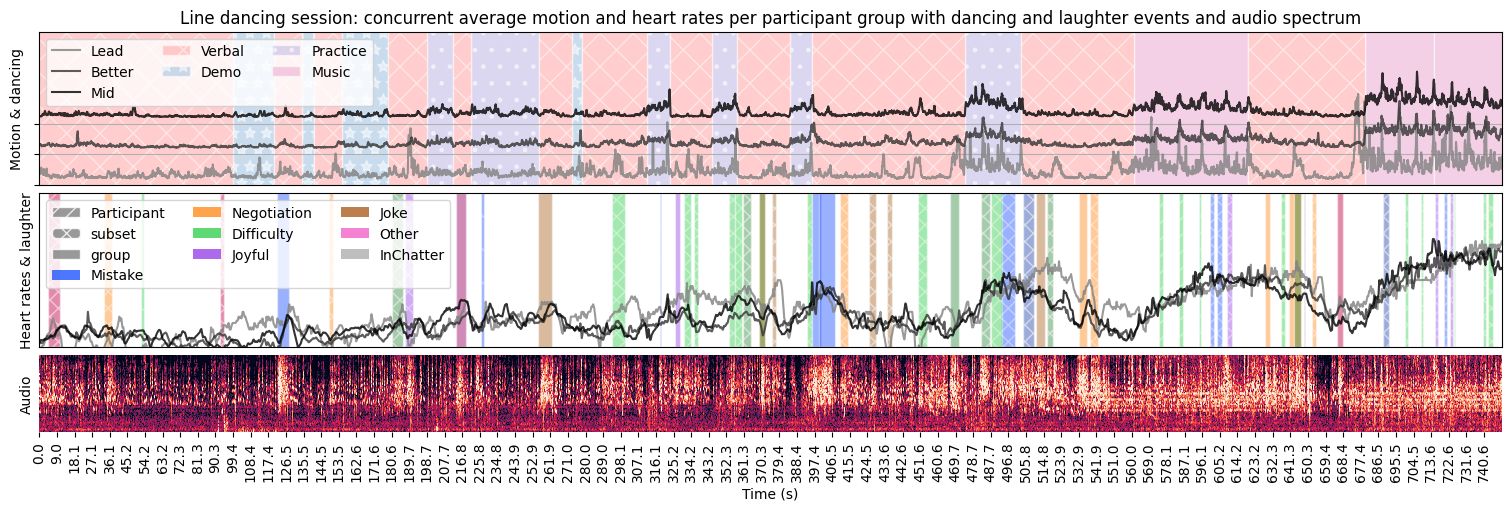

In [26]:
s_time = times[0]
e_time = times[-1]

sub_events = Event_timings.query('TIME+DURATION>=@s_time and TIME<@e_time')
sub_eventTypes = list(sub_events.Trial_Type.unique())

sect_tags = list(sections.keys())

fig3 = plt.figure(constrained_layout=True,figsize=(15,5))
gs = fig3.add_gridspec(5, 3)
axes={}
axes[0] = fig3.add_subplot(gs[0:2, :])
axes[1] = fig3.add_subplot(gs[2:4, :])
axes[2] = fig3.add_subplot(gs[4, :])

ax=axes[0]
df_feat =  df_allfeats['ACC_QoM'].copy()
shift_d = 50
for sect_i in range(len(sect_tags)):
    sect = sect_tags[sect_i]
    ax.plot(df_feat[sections[sect]].mean(axis=1)+sect_i*shift_d,color =section_pallet[sect],alpha=0.8,label=sect )

for ev in sub_eventTypes: ax.axvspan(-1,-0.5, facecolor=eventType_pallet[ev],hatch=eventType_hatching[ev],edgecolor="w",alpha = 0.5,label=ev)
# ax.legend(loc='upper left')
for ev in eventType_pallet.keys():
        viz.annat_shade(ax,Event_timings.query('Trial_Type==@ev'),eventType_pallet[ev],eventType_hatching[ev],0.5)
ax.legend(ncol=3,loc='upper left')
ax.set(xlim = [s_time,e_time],ylim = [0,5*shift_d],xticks=[],yticks=[0,shift_d,2*shift_d])
ax.set(yticklabels=[],ylabel='Motion & dancing') 
ax.grid()
ax.set_title('Line dancing session: concurrent average motion and heart rates per participant group with dancing and laughter events and audio spectrum')

ax=axes[1]
A = laughs.loc[:,whats].sum()
sub_whats = list(A[A>0].index)
for who in ['Participant','subset', 'group']:
    ax.axvspan(-1,-0.5, facecolor='gray',hatch = who_hatch[who],edgecolor="w",alpha = 0.8,label=who)
for what in sub_whats: ax.axvspan(-1,-0.5, facecolor=what_palette[what],alpha = 0.7,label=what)
ax.legend(ncol=3,loc='upper left')

df_feat =  df_allfeats['normHR1bt_smoothed'].copy()
for sect_i in range(len(sect_tags)):
    sect = sect_tags[sect_i]
    ax.plot(df_feat[sections[sect]].mean(axis=1),color =section_pallet[sect],alpha=0.8,label=sect )
ax.set(xlim = [s_time,e_time],ylim = [0,1.5],xticks=[],yticks=[])
ax.grid()
ax.set(yticklabels=[],ylabel='Heart rates & laughter') 
for who in ['subset', 'Lead', 'few', 'group', 'Participant']:
    sub_laughs = laughs.query('Who.str.startswith(@who)')
    for what in whats:
        viz.annat_shade(ax,sub_laughs.query(what+'==1'),what_palette[what],who_hatch[who],0.4)
        
ax=axes[2] 
A = df_allfeats['Audio_cqt'].set_index(np.round(df_allfeats['Audio_cqt'].index,1),drop=True)
chart = sns.heatmap(data=A.loc[s_time:e_time,:].transpose(),cmap="rocket",vmin =-70,vmax=-30,ax=ax,cbar = False,fmt='.1f')
ax.set(yticks=[],ylabel='Audio') 
ax.set_xlabel('Time (s)')

mydpi  = 192
plt.savefig('./Plots/LineDancing_Full_Annotated_Events_Laughs_Audio.png',bbox_inches = 'tight',dpi = mydpi)

plt.show()

## Plot excerpts of session


44    Trepidation at suggestion of full speed  laugh...
45         Scattered laughter at Many of you can get it
46            Laughter at "Just bounce, not in the way"
47                                   First aid kit joke
48                     Laughter with chatter background
49                            Finn Laughter at bad idea
50                        Laughter about math attention
51                                    Scattered giggles
52                                    Scattered giggles
53                                    Scattered giggles
54                          Laughter at success 4 turns
Name: LABEL, dtype: object


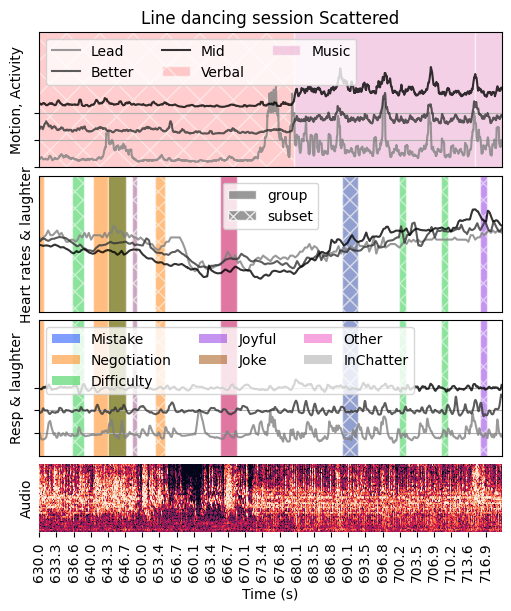

In [28]:
# Line {'Lead_Mistake':80,'Difficulty': 340, 'Scattered':630, 'seg4':320, 'Too_Fast':440 }
seg_tag ='Scattered'
s_time = 630#times[0]
e_time = s_time + 90 #altT[-1]# 3376.0 #760.0 #times[-1]

sub_events = Event_timings.query('TIME+DURATION>=@s_time and TIME<@e_time')
sub_eventTypes = list(sub_events.Trial_Type.unique())
                      
sub_dancings =  Event_timings.query('TIME+DURATION>=@s_time and TIME<@e_time')

sub_laughs = laughs.query('TIME+DURATION>=@s_time and TIME<@e_time')
print(sub_laughs.LABEL)
A = sub_laughs.loc[:,whats].sum()
sub_whats = list(A[A>0].index)
sub_who = list(sub_laughs.Who.unique())

fig3 = plt.figure(constrained_layout=True,figsize=(5,6))
gs = fig3.add_gridspec(7, 1)
axes={}
axes[0] = fig3.add_subplot(gs[0:2, :])
axes[1] = fig3.add_subplot(gs[2:4, :])
axes[2] = fig3.add_subplot(gs[4:6, :])
axes[3] = fig3.add_subplot(gs[6, :])

ax=axes[0]

df_feat =  df_allfeats['ACC_QoM'].loc[s_time:e_time,:].copy()
shift_d = 50
for sect_i in range(len(sect_tags)):
    sect = sect_tags[sect_i]
    ax.plot(df_feat[sections[sect]].mean(axis=1)+sect_i*shift_d,color =section_pallet[sect],alpha=0.8,label=sect )
for ev in sub_eventTypes: ax.axvspan(-1,-0.5, facecolor=eventType_pallet[ev],hatch=eventType_hatching[ev],edgecolor="w",alpha = 0.5,label=ev)
ax.legend(ncol=3,loc='best')
for ev in eventType_pallet.keys():
        viz.annat_shade(ax,sub_events.query('Trial_Type==@ev'),eventType_pallet[ev],eventType_hatching[ev],0.5)
ax.set_title('Line dancing session '+seg_tag)
ax.set(xlim = [s_time,e_time],ylim = [0,5*shift_d],xticks=[],yticks = [0,shift_d,2*shift_d])
ax.set(yticklabels=[],ylabel='Motion, Activity') 
ax.grid()

ax=axes[1]
for who in sub_who: ax.axvspan(-1,-0.5, facecolor='gray',hatch = who_hatch[who],edgecolor="w",alpha = 0.8,label=who)
ax.legend(loc='best')
df_feats = df_allfeats['normHR1bt'].loc[s_time:e_time,:].copy()
for sect_i in range(len(sect_tags)):
    sect = sect_tags[sect_i]
    ax.plot(df_smoothed[sections[sect]].mean(axis=1),color =section_pallet[sect],alpha=0.8,label=sect )
ax.set(yticklabels=[],ylabel='Heart rates & laughter') 
for who in ['subset', 'few', 'group', 'Participant','Lead']:
    sub_sub_laughs = sub_laughs.query('Who.str.startswith(@who)')
    for what in whats:
        viz.annat_shade(ax,sub_sub_laughs.query(what+'>0'),what_palette[what],who_hatch[who],0.5)      
ax.set(xlim = [s_time,e_time],ylim = [-0.3,1.5],xticks=[],yticks=[])
ax.grid()

ax=axes[2]
for what in sub_whats: ax.axvspan(-1,-0.5, facecolor=what_palette[what],alpha = 0.5,label=what)
ax.legend(ncol=3,loc='best')
df_feat = df_allfeats['RespWave'].loc[s_time:e_time,:].copy()
shift_d = 5
for sect_i in range(len(sect_tags)):
    sect = sect_tags[sect_i]
    sectMean = df_feat[sections[sect]].mean(axis=1)
    ax.plot(sectMean - sectMean.mean() +sect_i*shift_d,color =section_pallet[sect],alpha=0.8,label=sect )
# ax.legend()
ax.set(yticklabels=[],ylabel='Resp & laughter') 
for who in ['subset', 'few', 'group', 'Participant','Lead']:
    sub_sub_laughs = sub_laughs.query('Who.str.startswith(@who)')
    for what in whats:
        viz.annat_shade(ax,sub_sub_laughs.query(what+'>0'),what_palette[what],who_hatch[who],0.5)      
ax.set(xlim = [s_time,e_time],ylim = [-shift_d,5*shift_d],xticks=[],yticks = [0,shift_d,2*shift_d])
ax.grid()

ax=axes[3] 

A = df_allfeats['Audio_cqt'].set_index(np.round(df_allfeats['Audio_cqt'].index,1),drop=True)
chart = sns.heatmap(data=A.loc[s_time:e_time,:].transpose(),cmap="rocket",vmin =-70,vmax=-30,ax=ax,cbar = False,fmt='.1f')
ax.set(yticks=[],ylabel='Audio') 
ax.set_xlabel('Time (s)')

mydpi  = 192
plt.savefig('./Plots/Line_'+seg_tag+'_'+piece+'_Cascade_HR_QoM_audio.png',bbox_inches = 'tight',dpi = mydpi)
plt.show()

# Laugh Counts

In [30]:
Laugh_Counts = pd.DataFrame(index = whats, columns = events_types,data = 0)
for i,row in Event_timings.iterrows():
    s_time = row['StartTime']
    e_time = row['EndTime']
    sub_laughs = laughs.query('TIME+DURATION>=@s_time and TIME<@e_time')
    Laugh_Counts.loc[whats,row['Trial_Type']]+=sub_laughs.loc[:,whats].sum()

Laugh_Counts

,Demo,Practice,Music,Verbal,Applause
Mistake,0,3,4,4,0
Negotiation,0,1,0,14,0
Difficulty,0,5,8,14,0
Novelty,0,0,0,0,0
Joyful,0,0,3,3,0
Joke,0,0,0,5,0
Other,0,0,0,4,0
InChatter,0,2,1,11,0


In [31]:
print(Laugh_Counts.to_latex())

\begin{tabular}{lrrrrr}
\toprule
 & Demo & Practice & Music & Verbal & Applause \\
\midrule
Mistake & 0 & 3 & 4 & 4 & 0 \\
Negotiation & 0 & 1 & 0 & 14 & 0 \\
Difficulty & 0 & 5 & 8 & 14 & 0 \\
Novelty & 0 & 0 & 0 & 0 & 0 \\
Joyful & 0 & 0 & 3 & 3 & 0 \\
Joke & 0 & 0 & 0 & 5 & 0 \\
Other & 0 & 0 & 0 & 4 & 0 \\
InChatter & 0 & 2 & 1 & 11 & 0 \\
\bottomrule
\end{tabular}



In [32]:
# s_time = 0
# e_time = 760.0
Laugh_Counts = pd.DataFrame()

whos = ['group']
sub_laughs = laughs.query('TIME+DURATION>=@s_time and TIME<@e_time and Who in @whos')
B = (sub_laughs.loc[:,['Mistake', 'Negociation', 'Difficulty', 'Novelty', 'Joyful', 'Joke','Other']]>0.75).sum()
C = (sub_laughs.loc[:,['Mistake', 'Negociation', 'Difficulty', 'Novelty', 'Joyful', 'Joke','Other']]==0.5).sum()
Laugh_Counts.loc[:,'Group'] = B
# Laugh_Counts.loc[:,'Group_amb'] = C
# C

whos = ['few','subset']
sub_laughs = laughs.query('TIME+DURATION>=@s_time and TIME<@e_time and Who in @whos')
B = (sub_laughs.loc[:,['Mistake', 'Negociation', 'Difficulty', 'Novelty', 'Joyful', 'Joke','Other']]>0.75).sum()
C = (sub_laughs.loc[:,['Mistake', 'Negociation', 'Difficulty', 'Novelty', 'Joyful', 'Joke','Other']]==0.5).sum()
Laugh_Counts.loc[:,'Subset'] = B
# Laugh_Counts.loc[:,'Subset_amb'] = C

whos = ['Participant', 'Lead']
sub_laughs = laughs.query('TIME+DURATION>=@s_time and TIME<@e_time and Who in @whos')
B = (sub_laughs.loc[:,['Mistake', 'Negociation', 'Difficulty', 'Novelty', 'Joyful', 'Joke','Other']]>0.75).sum()
C = (sub_laughs.loc[:,['Mistake', 'Negociation', 'Difficulty', 'Novelty', 'Joyful', 'Joke','Other']]==0.5).sum()
Laugh_Counts.loc[:,'Solo'] = B
# Laugh_Counts.loc[:,'Solo_amb'] = C

Laugh_Counts

,Group,Subset,Solo
Mistake,0,1,0
Negociation,0,0,0
Difficulty,0,3,0
Novelty,0,0,0
Joyful,0,2,0
Joke,0,0,0
Other,0,0,0


In [33]:
print(Laugh_Counts.to_latex())

\begin{tabular}{lrrr}
\toprule
 & Group & Subset & Solo \\
\midrule
Mistake & 0 & 1 & 0 \\
Negociation & 0 & 0 & 0 \\
Difficulty & 0 & 3 & 0 \\
Novelty & 0 & 0 & 0 \\
Joyful & 0 & 2 & 0 \\
Joke & 0 & 0 & 0 \\
Other & 0 & 0 & 0 \\
\bottomrule
\end{tabular}

